# Practice 12 - Training Pipeline

준비된 DataLoader 를 사용해 **모델을 학습**합니다.

| 단계 | 내용 |
|------|------|
| 데이터 준비 | digits 60/20/20 분할 + 표준화 + DataLoader |
| 모델 정의 | `nn.Module` 상속 클래스 |
| Loss + Optimizer | `CrossEntropyLoss`, `Adam` |
| `train` / `evaluate` 함수 | 학습 루프를 함수로 묶어 재사용 가능한 형태로 |
| 학습 + 시각화 | Loss/Accuracy 학습 곡선 |
| 최종 test 평가 | 학습 완료 후 test set 에서 1회 평가 |
| 훈련 결과 시각화 | 예측 샘플 + Confusion Matrix |


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

# GPU 자동 선택 (CPU 환경이면 .to(device) 는 자동 무시됨)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# 데이터 준비
digits = load_digits()
X = digits.data
y = digits.target

# 60/20/20 train/val/test 분할
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 표준화 - train 통계량을 val, test 에 동일 적용
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)
train_std[train_std == 0] = 1.0   # 분산이 0인 특징(항상 같은 값)은 그대로 두기
X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=16, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=16, shuffle=False)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=16, shuffle=False)

print(f'Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}')


device: cuda
Train: 1077, Val: 360, Test: 360


---
## Train / Validation / Test 의 역할

| 세트 | 학습 중 사용 | 용도 |
|------|--------------|------|
| Train | 매 batch | 가중치 업데이트 |
| Validation | 매 epoch 평가 | 일반화 성능 모니터링 (조기 종료·하이퍼파라미터 선택 기준) |
| Test | **사용 안 함** | 학습이 모두 끝난 후 마지막에 1회만 평가 |

> Test set 을 학습 도중 모니터링에 사용하면 모델이 간접적으로 test 에 맞춰지게 됩니다(**data leakage**). 그래서 `train` 함수는 train_loader 와 val_loader 만 받고, test_loader 는 학습이 모두 끝난 뒤 별도로 한 번만 호출합니다.


---
# 1. 모델 정의 (nn.Module)

In [2]:
class DigitMLP(nn.Module):
    # 간단한 3층 MLP: 64 -> 128 -> 64 -> 10
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.net(x)

model = DigitMLP().to(device)
print(model)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print()
print(f'Total parameters: {total_params:,}')


DigitMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total parameters: 17,226


---
# 2. Loss, Optimizer 설정

In [3]:
# CrossEntropyLoss: softmax + NLL loss (내부에서 softmax 자동 적용)
criterion = nn.CrossEntropyLoss()

# Adam optimizer
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(f'Loss     : {criterion}')
print(f'Optimizer: Adam (lr={lr})')

Loss     : CrossEntropyLoss()
Optimizer: Adam (lr=0.001)


---
# 3. `train` + `evaluate` 함수

매 epoch 학습 루프를 직접 작성하는 대신 **두 함수로 묶어** 두면 이후 다른 모델·데이터에 그대로 재사용할 수 있습니다.

| 함수 | 역할 |
|------|------|
| `train(model, train_loader, val_loader, optimizer, epochs, device)` | epochs 만큼 학습 + 매 epoch val 평가, `(train_losses, train_accs, val_losses, val_accs)` 반환 |
| `evaluate(model, loader, device)` | 한 번 평가, `(loss, accuracy)` 반환 |

- `train` 함수는 학습 중 **val_loader 로만 모니터링** — test_loader 는 보지 않습니다
- `model.train()` / `model.eval()` 모드 전환은 함수가 내부에서 처리
- `device` 인자: CPU/GPU 어디서든 동일 코드 (CPU 환경이면 `.to(device)` 는 무시됨)
- 매 epoch 의 loss 는 **배치별 평균 loss 를 모두 더한 뒤 배치 개수로 나눠** 계산 (`loss_sum / len(loader)`)
- train accuracy 는 epoch 중 가중치가 계속 갱신되므로 "에폭 평균치" 라는 점만 알고 사용


In [4]:
# 학습 - epochs 만큼 학습 + 매 epoch val 평가
# (train_losses, train_accs, val_losses, val_accs) 반환
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
        train_loss = loss_sum / len(train_loader)
        train_acc = correct / count
        val_loss, val_acc, _ = evaluate(model, val_loader, device)   # y_pred 버림
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  '
                  f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
                  f'train_acc={train_acc:.4f}  val_acc={val_acc:.4f}')
    return train_losses, train_accs, val_losses, val_accs


# 평가 - (loss, accuracy, y_pred) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    preds = []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
            preds.append(output.argmax(1).cpu())
    y_pred = torch.cat(preds).numpy()
    return loss_sum / len(loader), correct / count, y_pred


---
# 4. 학습

In [5]:
train_losses, train_accs, val_losses, val_accs = train(
    model, train_loader, val_loader, optimizer, epochs=50, device=device)

print()
print(f'Final  train_loss={train_losses[-1]:.4f}  val_loss={val_losses[-1]:.4f}  '
      f'train_acc={train_accs[-1]:.4f}  val_acc={val_accs[-1]:.4f}')


  Epoch   1/50  train_loss=1.6321  val_loss=0.7804  train_acc=0.6481  val_acc=0.8611


  Epoch  10/50  train_loss=0.0112  val_loss=0.0704  train_acc=1.0000  val_acc=0.9667


  Epoch  20/50  train_loss=0.0020  val_loss=0.0567  train_acc=1.0000  val_acc=0.9750


  Epoch  30/50  train_loss=0.0007  val_loss=0.0534  train_acc=1.0000  val_acc=0.9750


  Epoch  40/50  train_loss=0.0003  val_loss=0.0509  train_acc=1.0000  val_acc=0.9833


  Epoch  50/50  train_loss=0.0002  val_loss=0.0498  train_acc=1.0000  val_acc=0.9833

Final  train_loss=0.0002  val_loss=0.0498  train_acc=1.0000  val_acc=0.9833


---
# 5. 학습 곡선 시각화

Loss 와 Accuracy 모두 train · validation 두 곡선을 함께 그려 **과적합 여부**를 확인합니다.

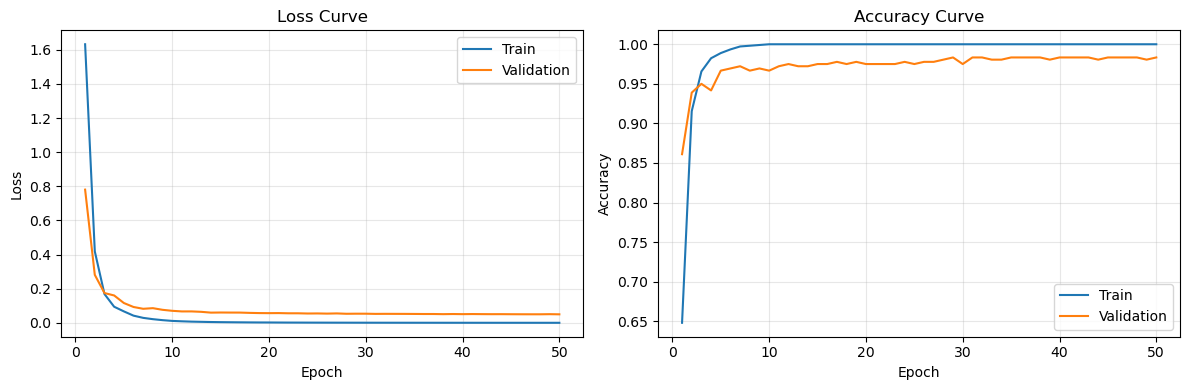

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='Train')
axes[0].plot(epochs_range, val_losses, label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accs, label='Train')
axes[1].plot(epochs_range, val_accs, label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
# 6. 최종 Test 평가

학습이 모두 끝났습니다. 이제 학습 중에 한 번도 보지 않은 **test set** 에서 한 번 평가합니다. 이 값이 모델의 일반화 성능에 대한 최종 결과입니다.

In [7]:
test_loss, test_acc, y_pred = evaluate(model, test_loader, device)
print(f'Final test_loss={test_loss:.4f}  test_acc={test_acc:.4f}')


Final test_loss=0.0727  test_acc=0.9833


---
# 7. 훈련 결과 시각화

직전 셀에서 받은 `y_pred` 로 (재예측 없이) 두 가지를 함께 봅니다.

- **틀린 예측 4 개**: 1 × 4 그리드, 제목 `True:X / Pred:Y` (빨강)
- **Confusion Matrix**: 어떤 숫자가 어떤 숫자로 오인되는지 한눈에 파악

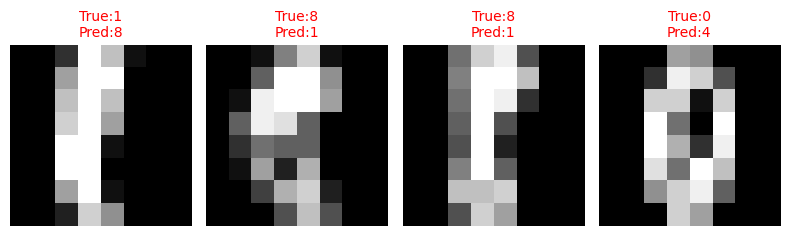

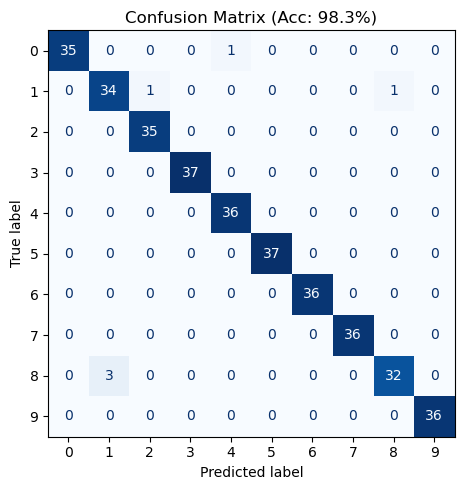

In [8]:

# (1) 틀린 예측 4 개 - 1 x 4 subplot
wrong_idx = np.where(y_pred != y_test)[0]
X_test_display = X_test * train_std + train_mean   # 표준화 역변환 - 원본 픽셀 (0~16) 로 복원
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for i in range(min(4, len(wrong_idx))):
    idx = wrong_idx[i]
    axes[i].imshow(X_test_display[idx].reshape(8, 8), cmap='gray')
    axes[i].set_title(f'True:{y_test[idx]}\nPred:{y_pred[idx]}', color='red', fontsize=10)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

# (2) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (Acc: {test_acc:.1%})')
plt.tight_layout(); plt.show()


---
## 정리

`train` + `evaluate` 두 함수로 학습 루프를 묶었습니다. 데이터·모델만 바꾸면 그대로 사용할 수 있는 표준 형태입니다.

- 학습 중에는 train + val 만 사용
- Test 는 학습 종료 후 한 번만 평가
- 예측 결과는 샘플 이미지와 Confusion Matrix 두 가지로 확인
